# GitHub Repository Mining & Graph Analysis

## Overview

This project focuses on analyzing GitHub repositories using **graph-based data mining techniques**.  
Each repository is represented as a **node**, and relationships between repositories (shared technologies or topics) are represented as **edges**.

The goal is to understand:
- Which repositories are most **important**
- Which are most **connected**
- How repositories influence each other in the network

---

## Project Objectives

- Build a repository **graph network**
- Identify **central and influential repositories**
- Analyze relationships using:
  - **Degree Centrality**
  - **PageRank**
  - **HITS Algorithm (Hub & Authority)**
- Visualize insights using graphs and dashboards

---

##Key Metrics Explained

###Degree Centrality
Measures how many direct connections a repository has.  
→ Indicates **popularity**

###PageRank
Measures importance based on the quality of connections.  
→ Indicates **influence**

### HITS Algorithm
- **Hub Score** → repositories that connect to important ones  
- **Authority Score** → repositories that are referenced by strong hubs  

---

## Dataset Description

The dataset consists of:
- Repository information (name, stars, language)
- Graph relationships between repositories
- Computed metrics:
  - Degree Centrality
  - PageRank
  - Hub Score
  - Authority Score

---

##Expected Output

- Identification of **top repositories**
- Understanding of **network structure**
- Visualization of:
  - Graph network
  - Centrality rankings
  - Relationships between repositories

---

##Goal

Build a **data-driven understanding** of GitHub ecosystem structure and identify the most influential repositories.

In [5]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [6]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

nodes_path = "/content/drive/MyDrive/mining/graph_nodes.csv"
edges_path = "/content/drive/MyDrive/mining/graph_edges.csv"

nodes_df = pd.read_csv(nodes_path)
edges_df = pd.read_csv(edges_path)

print("Nodes shape:", nodes_df.shape)
print("Edges shape:", edges_df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Nodes shape: (3562, 3)
Edges shape: (850247, 3)


In [7]:
nodes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3562 entries, 0 to 3561
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        3562 non-null   object
 1   stars     3562 non-null   int64 
 2   language  3562 non-null   object
dtypes: int64(1), object(2)
memory usage: 83.6+ KB


In [8]:
edges_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850247 entries, 0 to 850246
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   source  850247 non-null  object
 1   target  850247 non-null  object
 2   weight  850247 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 19.5+ MB


In [9]:
nodes_df.head()

,id,stars,language
0,tensorflow/tensorflow,194931,c++
1,f/prompts.chat,161118,html
2,huggingface/transformers,160082,python
3,pytorch/pytorch,99523,python
4,rasbt/LLMs-from-scratch,91705,jupyter notebook


In [10]:
edges_df.head()

,source,target,weight
0,huggingface/transformers,tensorflow/tensorflow,3
1,pytorch/pytorch,tensorflow/tensorflow,4
2,rasbt/LLMs-from-scratch,tensorflow/tensorflow,3
3,Developer-Y/cs-video-courses,tensorflow/tensorflow,2
4,d2l-ai/d2l-zh,tensorflow/tensorflow,3


In [11]:
print("Missing values in nodes:")
display(nodes_df.isnull().sum())

print("Missing values in edges:")
display(edges_df.isnull().sum())

Missing values in nodes:


,0
id,0
stars,0
language,0


Missing values in edges:


,0
source,0
target,0
weight,0


In [12]:
node_id_col = "id"  #repo name
source_col = "source" # start destantion
target_col = "target" # end destantion

In [13]:
valid_nodes = set(nodes_df[node_id_col])

edges_df = edges_df[
    edges_df[source_col].isin(valid_nodes) &
    edges_df[target_col].isin(valid_nodes)
]

print("Valid edges shape:", edges_df.shape)

Valid edges shape: (850247, 3)


In [14]:
G = nx.Graph()

for _, row in nodes_df.iterrows():
    node_id = row[node_id_col]
    attributes = row.to_dict()
    G.add_node(node_id, **attributes)

for _, row in edges_df.iterrows():
    source = row[source_col]
    target = row[target_col]
    G.add_edge(source, target)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 3562
Number of edges: 850247


In [15]:
graph_info = {
    "Number of Nodes": G.number_of_nodes(),
    "Number of Edges": G.number_of_edges(),
    "Density": nx.density(G),
    "Is Connected": nx.is_connected(G) if G.number_of_nodes() > 0 else False,
    "Number of Connected Components": nx.number_connected_components(G)
}

graph_info

{'Number of Nodes': 3562,
 'Number of Edges': 850247,
 'Density': 0.13406308689762653,
 'Is Connected': True,
 'Number of Connected Components': 1}

# **Degree Centrality**
Degree centrality was used to identify repositories with the highest number of connections.

The top repositories such as DocsGPT and instill-core have the highest degree centrality scores, indicating that they are highly connected to many other repositories.

This suggests that these repositories share common technologies or topics with a large portion of the network and can be considered central hubs in the repository graph.

In [16]:
degree_centrality = nx.degree_centrality(G)

degree_df = pd.DataFrame({
    "repository": list(degree_centrality.keys()),
    "degree_centrality": list(degree_centrality.values())
})

degree_df = degree_df.sort_values(by="degree_centrality", ascending=False)

degree_df.head(10)

,repository,degree_centrality
327,arc53/DocsGPT,0.446504
317,instill-ai/instill-core,0.441168
3025,flyteorg/flyte,0.435552
2399,GitHubDaily/GitHubDaily,0.434148
737,flwrlabs/flower,0.427970
171,rohitg00/ai-engineering-from-scratch,0.426566
220,tirthajyoti/Data-science-best-resources,0.420668
1480,cossacklabs/themis,0.415333
1238,the-akira/Computer-Science-Resources,0.413367
3067,modelfoxdotdev/modelfox,0.405504


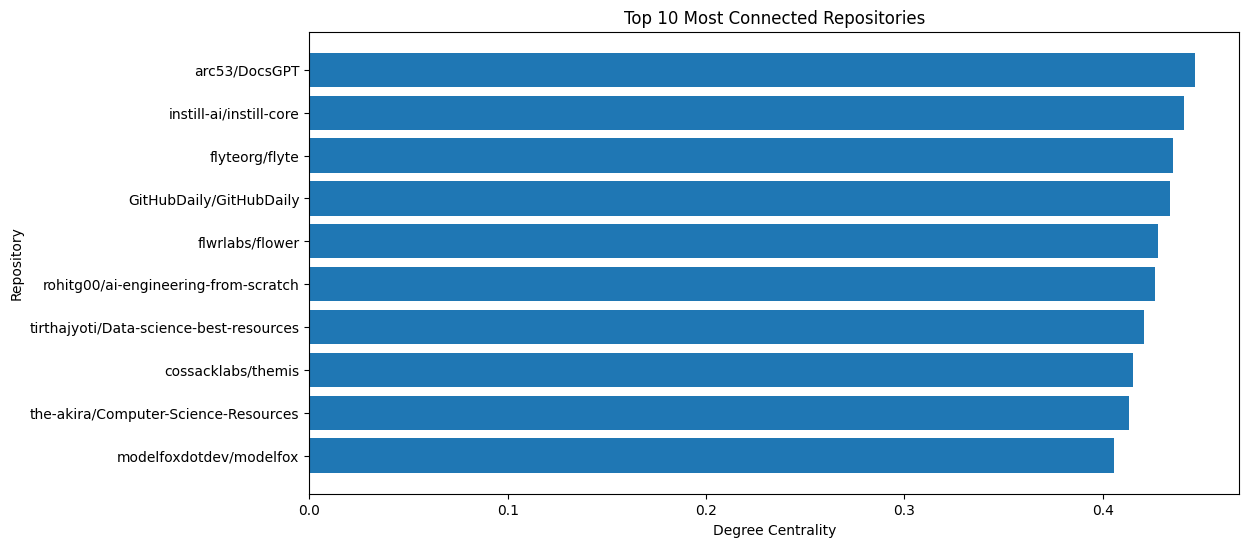

In [17]:
top_degree = degree_df.head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_degree["repository"].astype(str), top_degree["degree_centrality"])
plt.xlabel("Degree Centrality")
plt.ylabel("Repository")
plt.title("Top 10 Most Connected Repositories")
plt.gca().invert_yaxis()
plt.show()

# **PageRank Analysis**
PageRank is a graph-based algorithm used to measure the importance of nodes within a network.
Unlike simple connectivity measures, PageRank considers both the quantity and the quality of connections.

A repository receives a high PageRank score if it is connected to other important repositories.
This means that not all connections are equal—connections to highly influential repositories contribute more to the score.

The results show that repositories such as instill-core, GitHubDaily, and themis have the highest PageRank scores,
indicating that they are influential within the repository network and are connected to other important repositories.

Since PageRank values represent a probability distribution, the scores are small and sum up to approximately 1 across all nodes.
**Therefore, PageRank provides a deeper understanding of influence compared to simple degree centrality**

In [18]:
pagerank_scores = nx.pagerank(G, alpha=0.85)

pagerank_df = pd.DataFrame({
    "repository": list(pagerank_scores.keys()),
    "pagerank_score": list(pagerank_scores.values())
})

pagerank_df = pagerank_df.sort_values(by="pagerank_score", ascending=False)

pagerank_df.head(10)

,repository,pagerank_score
317,instill-ai/instill-core,0.000799
2399,GitHubDaily/GitHubDaily,0.000798
1480,cossacklabs/themis,0.000797
327,arc53/DocsGPT,0.000784
737,flwrlabs/flower,0.000775
3025,flyteorg/flyte,0.000773
171,rohitg00/ai-engineering-from-scratch,0.000761
1238,the-akira/Computer-Science-Resources,0.000760
220,tirthajyoti/Data-science-best-resources,0.000759
624,QuivrHQ/quivr,0.000755


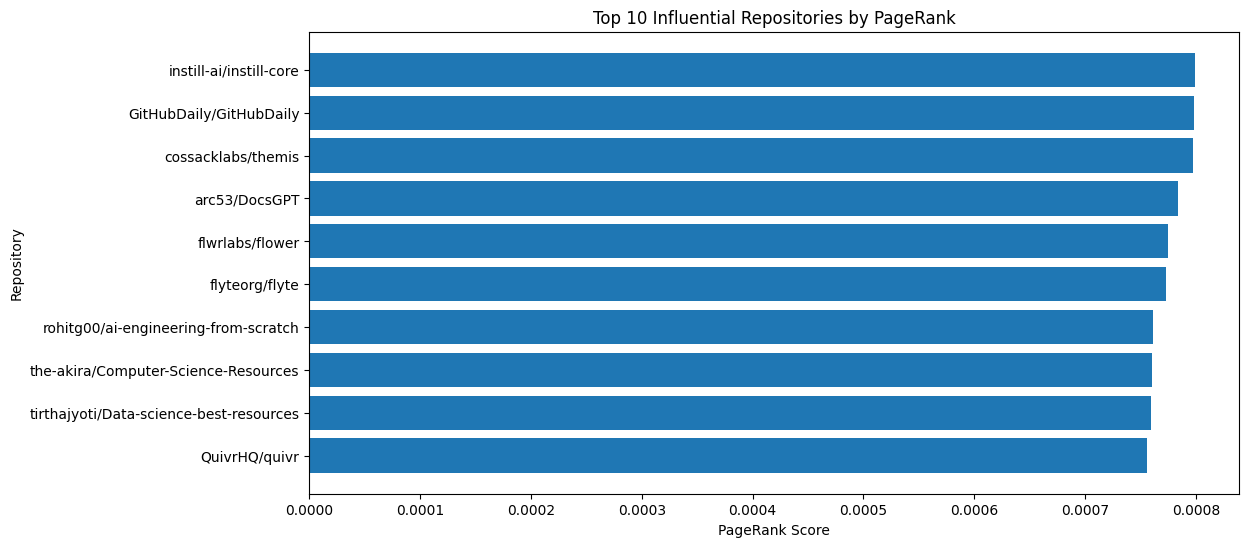

In [19]:
top_n = 10
top_pagerank = pagerank_df.head(top_n)

plt.figure(figsize=(12, 6))
plt.barh(top_pagerank["repository"].astype(str), top_pagerank["pagerank_score"])
plt.xlabel("PageRank Score")
plt.ylabel("Repository")
plt.title("Top 10 Influential Repositories by PageRank")
plt.gca().invert_yaxis()
plt.show()

# **The network graph visualization**
was created using the top 30 repositories based on PageRank scores.
The graph highlights central repositories that act as hubs, connecting multiple repositories within the network.

In [20]:
top_nodes = pagerank_df.head(30)["repository"].tolist()

In [21]:
subgraph = G.subgraph(top_nodes)

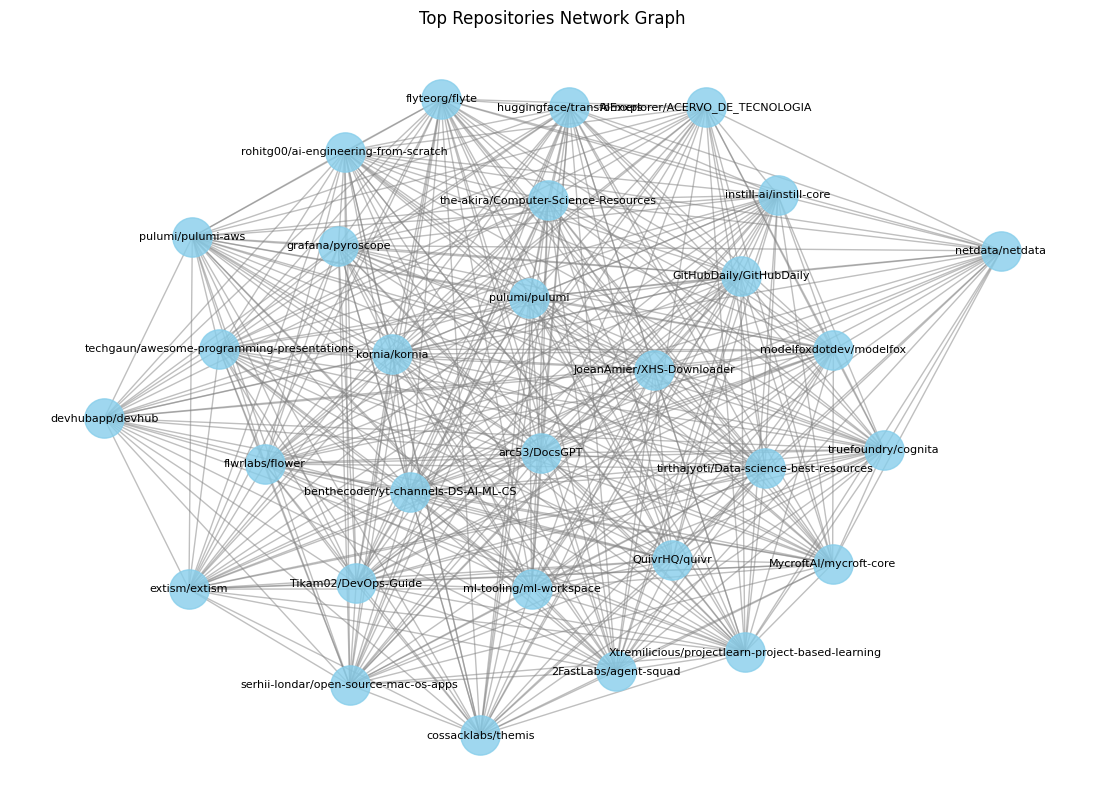

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

pos = nx.spring_layout(subgraph, seed=42)

nx.draw_networkx_nodes(
    subgraph,
    pos,
    node_size=800,
    node_color="skyblue",
    alpha=0.8
)

nx.draw_networkx_edges(
    subgraph,
    pos,
    edge_color="gray",
    alpha=0.5
)

nx.draw_networkx_labels(
    subgraph,
    pos,
    font_size=8
)

plt.title("Top Repositories Network Graph")
plt.axis("off")
plt.show()

The node color represents the PageRank score:
- Lighter / yellow nodes indicate higher PageRank scores, meaning they are more influential repositories.
- Darker / purple nodes indicate lower PageRank scores, meaning they are less influential compared to the lighter nodes.

This visualization helps identify the most influential repositories in the network and shows how they are connected to other important repositories.

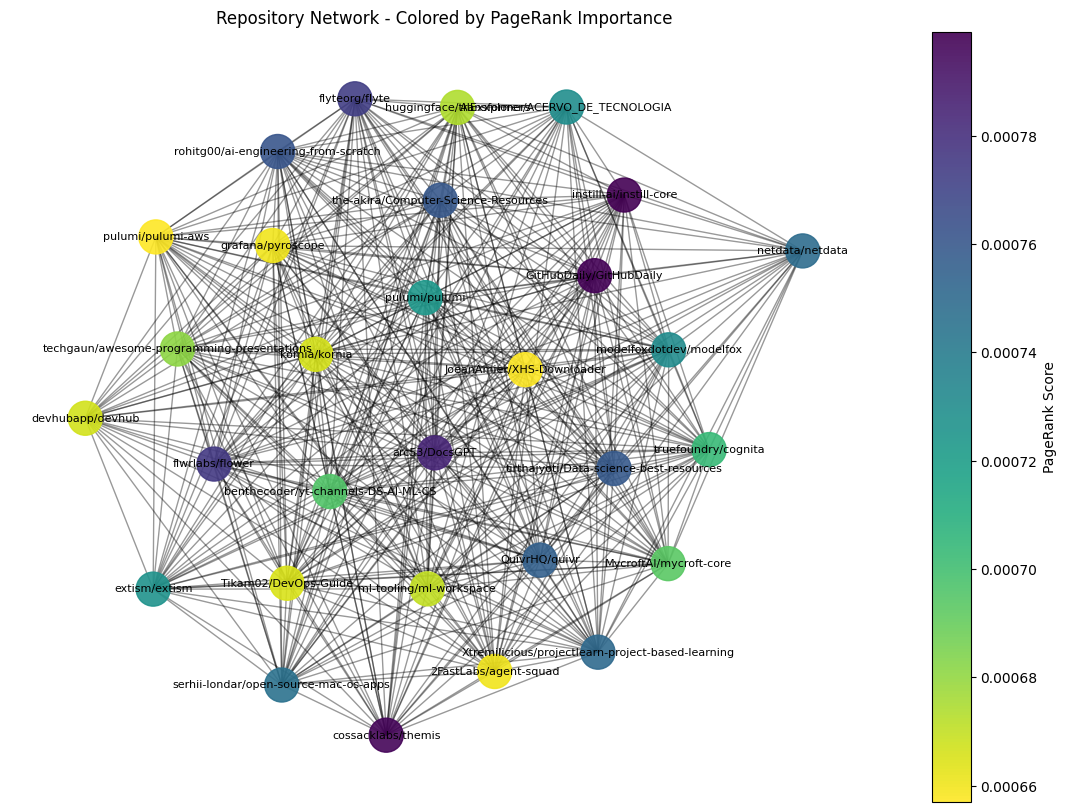

In [23]:
import matplotlib.pyplot as plt
import networkx as nx

top_nodes = pagerank_df.head(30)["repository"].tolist()
subgraph = G.subgraph(top_nodes)

plt.figure(figsize=(14, 10))

pos = nx.spring_layout(subgraph, seed=42)

node_colors = [
    pagerank_scores[node]
    for node in subgraph.nodes()
]

node_sizes = [600 for _ in subgraph.nodes()]

nodes = nx.draw_networkx_nodes(
    subgraph,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.viridis_r,
    alpha=0.9
)


nx.draw_networkx_edges(
    subgraph,
    pos,
    alpha=0.4
)

nx.draw_networkx_labels(
    subgraph,
    pos,
    font_size=8
)

plt.colorbar(nodes, label="PageRank Score")
plt.title("Repository Network - Colored by PageRank Importance")
plt.axis("off")
plt.show()

# **HITS algorithm was applied to identify hub and authority repositories in the graph.**

A hub repository is a repository that connects to many important repositories, while an authority repository is a repository that is highly connected by strong hubs.

The repositories were ranked based on authority score to identify the most authoritative repositories in the network.

In [24]:
hubs, authorities = nx.hits(G, max_iter=1000, normalized=True)

hits_df = pd.DataFrame({
    "repository": list(hubs.keys()),
    "hub_score": list(hubs.values()),
    "authority_score": list(authorities.values())
})

hits_df = hits_df.sort_values(by="authority_score", ascending=False)

hits_df.head(10)

,repository,hub_score,authority_score
327,arc53/DocsGPT,0.001085,0.001085
3025,flyteorg/flyte,0.001041,0.001041
171,rohitg00/ai-engineering-from-scratch,0.001037,0.001037
2,huggingface/transformers,0.001021,0.001021
286,truefoundry/cognita,0.001019,0.001019
737,flwrlabs/flower,0.001008,0.001008
220,tirthajyoti/Data-science-best-resources,0.000999,0.000999
422,kornia/kornia,0.000984,0.000984
3052,kubeflow/trainer,0.000983,0.000983
796,benthecoder/yt-channels-DS-AI-ML-CS,0.000983,0.000983


In [25]:
results_df = degree_df.merge(pagerank_df, on="repository")
results_df = results_df.merge(hits_df, on="repository")

results_df = results_df.sort_values(by="pagerank_score", ascending=False)
results_df.head(10)

,repository,degree_centrality,pagerank_score,hub_score,authority_score
1,instill-ai/instill-core,0.441168,0.000799,0.000971,0.000971
3,GitHubDaily/GitHubDaily,0.434148,0.000798,0.000926,0.000926
7,cossacklabs/themis,0.415333,0.000797,0.000807,0.000807
0,arc53/DocsGPT,0.446504,0.000784,0.001085,0.001085
4,flwrlabs/flower,0.427970,0.000775,0.001008,0.001008
2,flyteorg/flyte,0.435552,0.000773,0.001041,0.001041
5,rohitg00/ai-engineering-from-scratch,0.426566,0.000761,0.001037,0.001037
8,the-akira/Computer-Science-Resources,0.413367,0.000760,0.000959,0.000959
6,tirthajyoti/Data-science-best-resources,0.420668,0.000759,0.000999,0.000999
14,QuivrHQ/quivr,0.396518,0.000755,0.000673,0.000673


In [26]:
print("Top 5 Repositories by Degree Centrality-Identify influential repositories")
display(
    results_df
    .sort_values(by="degree_centrality", ascending=False)
    .head(5)
)

print("Top 5 Repositories by PageRank-Analyze which repositories are most central")
display(
    results_df
    .sort_values(by="pagerank_score", ascending=False)
    .head(5)
)

Top 5 Repositories by Degree Centrality-Identify influential repositories


,repository,degree_centrality,pagerank_score,hub_score,authority_score
0,arc53/DocsGPT,0.446504,0.000784,0.001085,0.001085
1,instill-ai/instill-core,0.441168,0.000799,0.000971,0.000971
2,flyteorg/flyte,0.435552,0.000773,0.001041,0.001041
3,GitHubDaily/GitHubDaily,0.434148,0.000798,0.000926,0.000926
4,flwrlabs/flower,0.427970,0.000775,0.001008,0.001008


Top 5 Repositories by PageRank-Analyze which repositories are most central


,repository,degree_centrality,pagerank_score,hub_score,authority_score
1,instill-ai/instill-core,0.441168,0.000799,0.000971,0.000971
3,GitHubDaily/GitHubDaily,0.434148,0.000798,0.000926,0.000926
7,cossacklabs/themis,0.415333,0.000797,0.000807,0.000807
0,arc53/DocsGPT,0.446504,0.000784,0.001085,0.001085
4,flwrlabs/flower,0.427970,0.000775,0.001008,0.001008


# **Difference Between Degree Centrality and PageRank**
Degree centrality and PageRank are both used to measure node importance in a graph, but they capture different aspects.

Degree centrality measures the number of direct connections a node has.
It treats all connections equally and focuses only on the **quantity** of relationships.

PageRank, on the other hand, evaluates the importance of a node based on the **importance of its neighbors**.
Connections to highly influential nodes contribute more to the score than connections to less important ones.

In summary:
- Degree centrality identifies popular nodes with many connections.
- PageRank identifies influential nodes connected to other important nodes.

Therefore, PageRank provides a more meaningful measure of influence in complex networks.

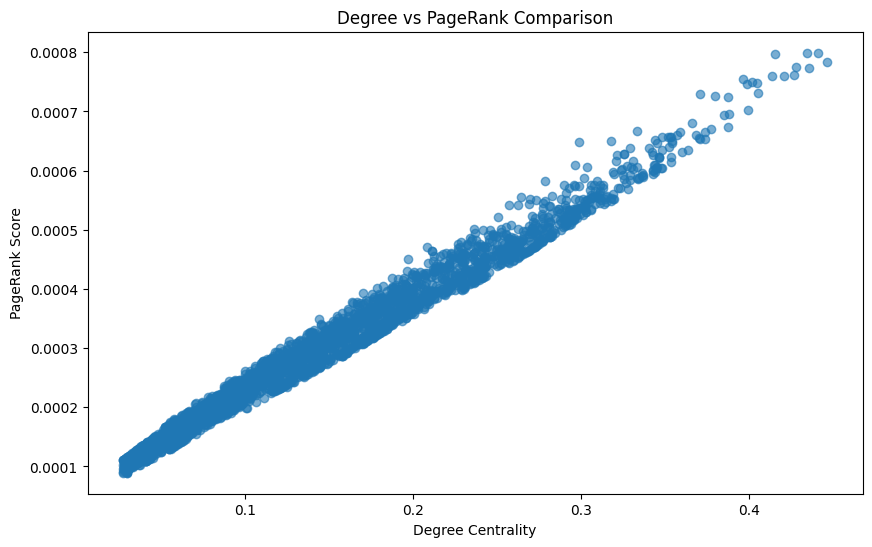

In [27]:
plt.figure(figsize=(10,6))

plt.scatter(
    results_df["degree_centrality"],
    results_df["pagerank_score"],
    alpha=0.6
)

plt.xlabel("Degree Centrality")
plt.ylabel("PageRank Score")
plt.title("Degree vs PageRank Comparison")

plt.show()

In [35]:
edges_df = pd.read_csv(edges_path)
# Check columns
edges_df.head()

,source,target,weight
0,huggingface/transformers,tensorflow/tensorflow,3
1,pytorch/pytorch,tensorflow/tensorflow,4
2,rasbt/LLMs-from-scratch,tensorflow/tensorflow,3
3,Developer-Y/cs-video-courses,tensorflow/tensorflow,2
4,d2l-ai/d2l-zh,tensorflow/tensorflow,3


In [36]:
# Count outgoing/incoming/total connections from graph_edges
source_counts = edges_df["source"].value_counts().rename("source_edge_count")
target_counts = edges_df["target"].value_counts().rename("target_edge_count")

edge_summary = pd.concat([source_counts, target_counts], axis=1).fillna(0)

edge_summary["total_edge_count"] = (
    edge_summary["source_edge_count"] + edge_summary["target_edge_count"]
)

edge_summary = edge_summary.reset_index().rename(columns={"index": "repository"})

edge_summary.head()

,repository,source_edge_count,target_edge_count,total_edge_count
0,GitHubDaily/GitHubDaily,1430.0,116.0,1546.0
1,AIExxplorer/ACERVO_DE_TECNOLOGIA,1307.0,14.0,1321.0
2,2FastLabs/agent-squad,1307.0,5.0,1312.0
3,MycroftAI/mycroft-core,1204.0,167.0,1371.0
4,ComposioHQ/composio,1186.0,47.0,1233.0


In [38]:
results = results_df.merge(
    nodes_df,
    left_on="repository",
    right_on=node_id_col,
    how="left"
)

In [37]:
final_results = results.merge(
    edge_summary,
    on="repository",
    how="left"
)

final_results[["source_edge_count", "target_edge_count", "total_edge_count"]] = (
    final_results[["source_edge_count", "target_edge_count", "total_edge_count"]]
    .fillna(0)
    .astype(int)
)

final_results.head(10)

,repository,degree_centrality,pagerank_score,hub_score,authority_score,id,stars,language,source_edge_count,target_edge_count,total_edge_count
0,instill-ai/instill-core,0.441168,0.000799,0.000971,0.000971,instill-ai/instill-core,2309,python,720,851,1571
1,GitHubDaily/GitHubDaily,0.434148,0.000798,0.000926,0.000926,GitHubDaily/GitHubDaily,46287,unknown,1430,116,1546
2,cossacklabs/themis,0.415333,0.000797,0.000807,0.000807,cossacklabs/themis,1962,c,983,496,1479
3,arc53/DocsGPT,0.446504,0.000784,0.001085,0.001085,arc53/DocsGPT,17860,python,1176,414,1590
4,flwrlabs/flower,0.427970,0.000775,0.001008,0.001008,flwrlabs/flower,6866,python,818,706,1524
5,flyteorg/flyte,0.435552,0.000773,0.001041,0.001041,flyteorg/flyte,6966,go,853,698,1551
6,rohitg00/ai-engineering-from-scratch,0.426566,0.000761,0.001037,0.001037,rohitg00/ai-engineering-from-scratch,5589,python,258,1261,1519
7,the-akira/Computer-Science-Resources,0.413367,0.000760,0.000959,0.000959,the-akira/Computer-Science-Resources,2760,unknown,132,1340,1472
8,tirthajyoti/Data-science-best-resources,0.420668,0.000759,0.000999,0.000999,tirthajyoti/Data-science-best-resources,3199,unknown,117,1381,1498
9,QuivrHQ/quivr,0.396518,0.000755,0.000673,0.000673,QuivrHQ/quivr,39120,python,1186,226,1412


In [29]:
final_results.to_csv("repository_link_analysis_results.csv", index=False)

print("Results saved")

Results saved


In [30]:
from google.colab import files

files.download("repository_link_analysis_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>